In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# df = pd.read_csv(r"C:\Users\PC\Downloads\creditcard.csv")
df = pd.read_csv(r"C:\Users\PC\Downloads\Churn_Modelling.csv")
target_column = 'Exited'  
result = {}
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and col != target_column:
        print(f"Column: {col}, Unique Values: {df[col].nunique()}")
        corr = df[col].corr(df[target_column])
        result[col] = corr
        print(f"Correlation with {target_column}: {corr}\n")
        print(result)
        




















# Creating for categorical columns
# plot_col_categorical = []
# for col in df.columns:
#     categorical_cols_values = df[col].unique()
    
#     if (df[col].dtype=='object' and len(categorical_cols_values) <10) or( len(categorical_cols_values) < 10):
#         plot_col_categorical.append(col)
#     else:
#         plot_col_categorical 
        

# sns.set_style("whitegrid")
# fig, axes = plt.subplots(1, len(plot_col_categorical), figsize=(3*len(plot_col_categorical), 3))
# if len(plot_col_categorical) == 1:
#     axes = [axes]  
# for i, col in enumerate(plot_col_categorical):
#     axes[i].set_title(f"{col} Distribution", fontweight='bold')
#     sns.countplot(x=col, data=df, ax=axes[i])
#     plt.xlabel(col)


# plt.suptitle("Distribution of Categorical Columns", fontsize=18, fontweight='bold')

# plt.tight_layout()
# plt.show()


Column: RowNumber, Unique Values: 10000
Correlation with Exited: -0.016571371463984734

{'RowNumber': np.float64(-0.016571371463984734)}
Column: CustomerId, Unique Values: 10000
Correlation with Exited: -0.006247986637818789

{'RowNumber': np.float64(-0.016571371463984734), 'CustomerId': np.float64(-0.006247986637818789)}
Column: CreditScore, Unique Values: 460
Correlation with Exited: -0.02709353975465779

{'RowNumber': np.float64(-0.016571371463984734), 'CustomerId': np.float64(-0.006247986637818789), 'CreditScore': np.float64(-0.02709353975465779)}
Column: Age, Unique Values: 70
Correlation with Exited: 0.28532303783506835

{'RowNumber': np.float64(-0.016571371463984734), 'CustomerId': np.float64(-0.006247986637818789), 'CreditScore': np.float64(-0.02709353975465779), 'Age': np.float64(0.28532303783506835)}
Column: Tenure, Unique Values: 11
Correlation with Exited: -0.014000612253444572

{'RowNumber': np.float64(-0.016571371463984734), 'CustomerId': np.float64(-0.006247986637818789)

In [18]:
central_memory = {
     "imbalance_class":{}
}
def detect_imbalance_features(file_path):
    try:
        cols = []
        percentages = {}

        df = pd.read_csv(file_path)
        for i in df.columns:
            val_len = df[i].nunique()
            if (df[i].dtype in ['int64', 'float64'] and val_len < 10 or df[i].dtype == 'object' and val_len < 10):
                cols.append(i)
        
        for categ_cols in cols:
            catg_percentages = df[categ_cols].value_counts()/len(df)  * 100
            percentages[categ_cols] = catg_percentages.to_dict()
        
        central_memory["imbalance_class"] = {
            "columns_with_few_categories": cols,
            "percentages": percentages
        }
    
    except Exception as e:
        print(f"An error occurred: {e}")

result = detect_imbalance_features(r"C:\Users\PC\Downloads\Churn_Modelling.csv")
print(central_memory)

{'imbalance_class': {'columns_with_few_categories': ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited'], 'percentages': {'Geography': {'France': 50.13999999999999, 'Germany': 25.09, 'Spain': 24.77}, 'Gender': {'Male': 54.56999999999999, 'Female': 45.43}, 'NumOfProducts': {1: 50.839999999999996, 2: 45.9, 3: 2.6599999999999997, 4: 0.6}, 'HasCrCard': {1: 70.55, 0: 29.45}, 'IsActiveMember': {1: 51.51, 0: 48.49}, 'Exited': {0: 79.63, 1: 20.369999999999997}}}}


In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df['NumOfProducts'].nunique()

4

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\PC\Downloads\Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


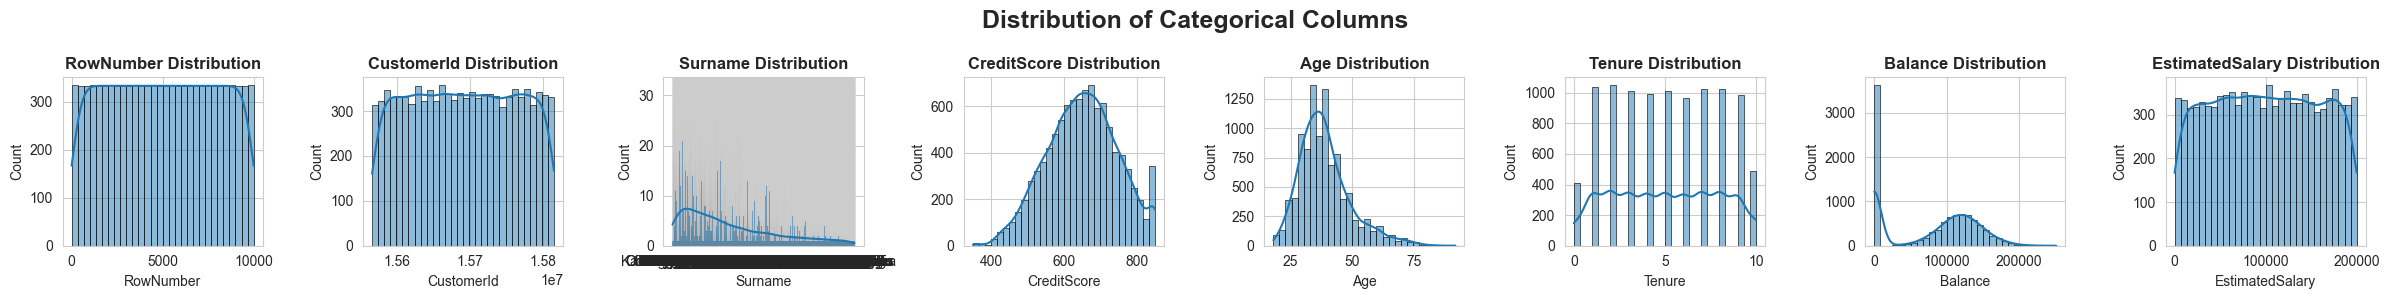

In [ ]:
# Numerical Columns

plot_col_num = []
for col in df.columns:
    num_columns_values = df[col].unique()
    
    if (df[col].dtype in ['int64', 'float64'] and len(num_columns_values) >10) or (len(num_columns_values)>10):
        plot_col_num.append(col)
    else:
        plot_col_num 
        

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, len(plot_col_num), figsize=(3*len(plot_col_num), 3))
if len(plot_col_num) == 1:
    axes = [axes]  
for i, col in enumerate(plot_col_num):
    axes[i].set_title(f"{col} Distribution", fontweight='bold')
    sns.histplot(x=col, data=df, ax=axes[i], kde=True, bins=30, edgecolor='black')
    plt.xlabel(col)


plt.suptitle("Distribution of Categorical Columns", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


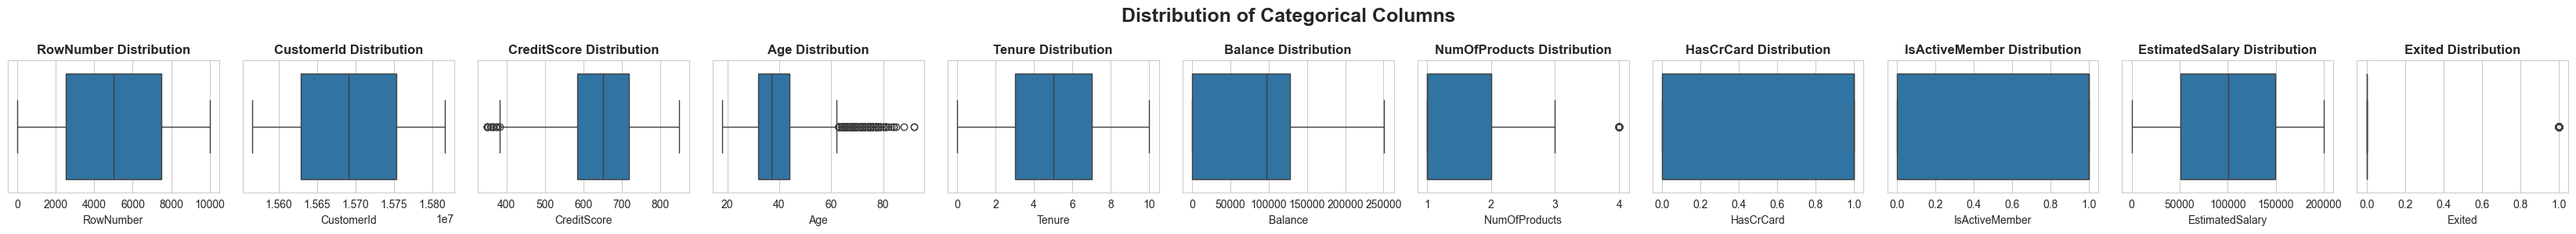

In [ ]:
# Boxplot

plot_col_num = []
for col in df.columns:
    num_columns_values = df[col].unique()
    
    if df[col].dtype in ['int64', 'float64']:
        plot_col_num.append(col)
    else:
        plot_col_num 
        
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, len(plot_col_num), figsize=(3*len(plot_col_num), 3))
if len(plot_col_num) == 1:
    axes = [axes]  
for i, col in enumerate(plot_col_num):
    axes[i].set_title(f"{col} Distribution", fontweight='bold')
    sns.boxplot(x=col, data=df, ax=axes[i])
    plt.xlabel(col)

plt.suptitle("Distribution of Categorical Columns", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


In [18]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
scatter_col_num = []

for col in df.columns:
    scatter_col_values = df[col].unique()

    if df[col].dtype in ['int64', 'float64']:
        scatter_col_num.append(col)
    else:
        scatter_col_num

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, len(scatter_col_num), figsize=(3*len(scatter_col_num), 3))
for i, names in enumerate(scatter_col_num):
    sns.scatterplot(x=names, y='Exited', data=df, ax=axes[i])